# Modellering af ikke-lineær elbelastning mod temperatur med PROC GAMPL


## Resumé

Elforbruget afhænger af temperaturen på en stærkt ikke-lineær, U-formet måde (opvarmning i kulde, køling i varme), som lineære modeller overser. Denne notebook opbygger en syntetisk timebaseret belastningsstikprøve for et regionalt forsyningsselskab og tilpasser en penaliseret generaliseret additiv model med **PROC GAMPL**, hvor regressionsplines bruges til at genskabe de glatte kurver for belastning-mod-temperatur, belastning-mod-time og belastning-mod-luftfugtighed, samtidig med at der justeres for en parametrisk hverdag/weekend-effekt.

På stikprøven på 100 observationer, som dette licenserede miljø leverer, genskaber GAMPL den struktur, vi har bygget ind. Temperaturglatningen `s(TEMP_C)` er signifikant kurvet (effektiv frihedsgrad 5.53, *p* < 0.0001); døgnglatningen `s(HOUR)` er det mest fleksible led (EDF 6.87, *p* < 0.0001); og luftfugtighedsglatningen `s(HUMIDITY)` kollapser til én, næsten lineær frihedsgrad (EDF 1.00, *p* = 0.07) — straffen retter et led ud, som dataene knap nok understøtter. Den parametriske `daytype`-effekt placerer weekender omkring 44.5 MW under hverdage, hvilket svarer til niveauskiftet på 40 MW i den dataskabende proces. Den samlede model bruger 15.4 effektive frihedsgrader og opnår en GCV-score på 239.6 (AIC 831.0).

## Datakilder

| Datasæt | Rækker | Beskrivelse | Nøglevariable |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Syntetiske timeobservationer fra et regionalt elselskabs belastningsprognosefeed | `load_mw` (systembelastning, MW), `temp_c` (omgivende temperatur, grader C), `hour` (time på dagen, 0-23), `humidity` (relativ luftfugtighed, %), `daytype` (Weekday/Weekend-klasse), `is_summer` (sæsonflag brugt i datagenerering) |

Alle data genereres direkte med `call streaminit(20260531)` og `rand()` — ingen ekstern eller netværksbaseret inputkilde. Data-trinnet anmoder om en større løkke, men dette licenserede miljø begrænser det materialiserede output til **100 observationer**, så modellen tilpasses de første 100 timer. Belastningen opbygges som en U-formet kvadratisk funktion af temperaturen plus en klokkeformet døgneffekt for timen, en mild luftfugtighedseffekt, et niveauskift for hverdage og gaussisk støj, så de genfundne glatninger har en kendt facitliste.

# Modellering af ikke-lineær elbelastning mod temperatur med PROC GAMPL

En regional netoperatør skal prognosticere systembelastningen (i megawatt) ud fra vejr- og kalenderdrivere. Sammenhængen mellem belastning og **temperatur** er berømt ikke-lineær: efterspørgslen stiger i koldt vejr (elopvarmning) *og* i varmt vejr (aircondition), hvilket giver en U-formet kurve, som en lineær regression ikke kan indfange. Belastningen følger også en glat daglig rytme (aftenspidsbelastningen) og skifter mellem hverdage og weekender.

`PROC GAMPL` tilpasser en **penaliseret generaliseret additiv model**: hver kontinuert driver indgår gennem en regressionsspline, hvis glathed vælges automatisk ved at minimere et modeludvælgelseskriterium (GCV / UBRE / GACV). Vi lader dataene bestemme, hvor bugtet hver kurve skal være, i stedet for at gætte på polynomiegrader.

Modellen, vi tilpasser, er:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

hvor `daytype` er en parametrisk (lineær) klasseeffekt, og `f1`, `f2`, `f3` er glatte spline-funktioner, hvis effektive frihedsgrader straffen udvælger fra dataene.

## Trin 1 — Generér et syntetisk timebaseret belastningsfeed

Vi simulerer et timebaseret belastningsfeed (det licenserede miljø beholder de første 100 timer). Temperaturen trækkes omkring et sæsonmiddel; timen på dagen cyklerer 0-23; luftfugtigheden følger løst temperaturen. Den *sande* belastning er konstrueret ud fra:

- en **U-formet** temperaturrespons centreret nær en behagelig 18 grader C,
- en **klokkeformet** døgntop omkring time 18 (aften),
- et mildt luftfugtighedsløft,
- et hverdagsniveau, der ligger over weekender,

plus gaussisk målestøj. Fordi vi kender de genererende kurver, kan vi vurdere, om GAMPL genskaber deres former. PROC MEANS-tjekket nedenfor bekræfter, at stikprøven spænder over et bredt temperaturinterval (−5 til 40 grader C) og belastning fra ca. 485 til 693 MW.

In [1]:
data work.gridload;
   CALL streaminit(20260531);
   GØR i = 1 TIL 2000;
      /* Season flag: roughly half summer, half winter */
      is_summer = (rand("uniform") < 0.5);

      /* Ambient temperature (deg C): warmer mean in summer */
      HVIS is_summer SÅ temp_c = 26 + 6 * rand("normal");
      ELLERS              temp_c =  6 + 6 * rand("normal");

      /* Hour of day 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Humidity (%) loosely tracks temperature, clipped to 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      HVIS humidity < 20  SÅ humidity = 20;
      HVIS humidity > 100 SÅ humidity = 100;

      /* Weekday vs weekend (about 5/7 weekdays) */
      HVIS rand("uniform") < 0.714 SÅ daytype = "Weekday";
      ELLERS                            daytype = "Weekend";

      /* ---- True structural load (MW) ---- */
      /* U-shaped temperature effect: minimum demand near 18 deg C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Diurnal bell: evening peak near hour 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Gentle humidity lift */
      f_hum  = 0.35 * humidity;

      /* Weekday level shift */
      HVIS daytype = "Weekday" SÅ f_day = 40; ELLERS f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      BEHOLD load_mw temp_c hour humidity daytype is_summer;
      UDDATA;
   SLUT;
KØR;

PROCEDURE GENNEMSNIT data=work.gridload n mean std MIN MAX maxdec=1;
   VARIABEL load_mw temp_c hour humidity;
   MÆRKAT load_mw="Belastning (MW)" temp_c="Temperatur (grader C)"
         hour="Time på dagen" humidity="Luftfugtighed (%)";
KØR;


                                                  The MEANS Procedure

 Variable  Label                         N        Mean     Std Dev     Minimum     Maximum
 -----------------------------------------------------------------------------------------
 load_mw   Belastning (MW)             100       593.0        49.9       484.9       693.4
 temp_c    Temperatur (grader C)       100        16.2        11.9        -5.2        40.2
 hour      Time på dagen               100        11.9         7.0         0.0        23.0
 humidity  Luftfugtighed (%)           100        55.2        11.7        32.2        87.3
 -----------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.44 seconds
  cpu   0.44 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Trin 2 — Tilpas den additive model

Vi modellerer `load_mw` (gaussisk respons, identitetslink) som en sum af en parametrisk `daytype`-effekt plus tre univariate splines. `PROC GAMPL` vælger automatisk hver splines udglatningsparameter. Vi angiver:

- `class daytype;`, så hverdag/weekend-indikatoren behandles som kategorisk,
- `param(daytype)` for at indføre den som et *parametrisk* (ikke-udglattet) led i MODEL,
- `spline(...)` for hver kontinuert prædiktor,
- en fast `seed=` for reproducerbar knudeplacering.

Outputtet, der skal læses, er tabellen **Smoothing Component**, som rapporterer de effektive frihedsgrader (EDF), straffen har tildelt hver glatning, samt en *F*-lignende signifikanstest for den, sammen med **Parameter Estimates** for konstantleddet og den parametriske `daytype`-kontrast.

In [2]:
PROCEDURE gampl data=work.gridload seed=20260531;
   KLASSE daytype;
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   MÆRKAT load_mw="Belastning (MW)" daytype="Dagstype" temp_c="Temperatur (grader C)"
         hour="Time på dagen" humidity="Luftfugtighed (%)";
KØR;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Belastning (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Dagstype

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                              


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Trin 3 — Styr splinefleksibiliteten og udvælgelseskriteriet

Som standard straffes hver glatning mod en lav effektiv frihedsgrad. For en operatør, der ved, at temperaturresponsen reelt er kurvet, men som vil *begrænse* bugtetheden, kan vi hæve `maxdf=` på temperatursplinen og fastsætte et beskedent fast `df=` på det glattere luftfugtighedsled. Vi skifter også til ydre-iterationsskemaet og vælger udglatningsparametre med **GCV** (generaliseret krydsvalidering), standardkriteriet for gaussiske GAM'er.

In [3]:
PROCEDURE gampl data=work.gridload seed=20260531;
   KLASSE daytype;
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   MÆRKAT load_mw="Belastning (MW)" daytype="Dagstype" temp_c="Temperatur (grader C)"
         hour="Time på dagen" humidity="Luftfugtighed (%)";
KØR;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Belastning (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Dagstype

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                              


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Trin 4 — Visualisér den genfundne temperaturrespons

GAMPL rapporterer *at* temperaturglatningen er signifikant kurvet (EDF 5.53), men formen er lettest at se på et plot. Vi lægger en penaliseret B-spline-tilpasning (`PBSPLINE`, samme regressionsspline-maskineri som GAMPL bruger internt) oven på den rå spredningsplot af belastning-mod-temperatur. Hvis den additive model har indfanget fysikken, bør denne kurve falde mod både det kolde og det varme yderpunkt og bunde i det behagelige midterinterval — den klassiske U-formede efterspørgselsrespons.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


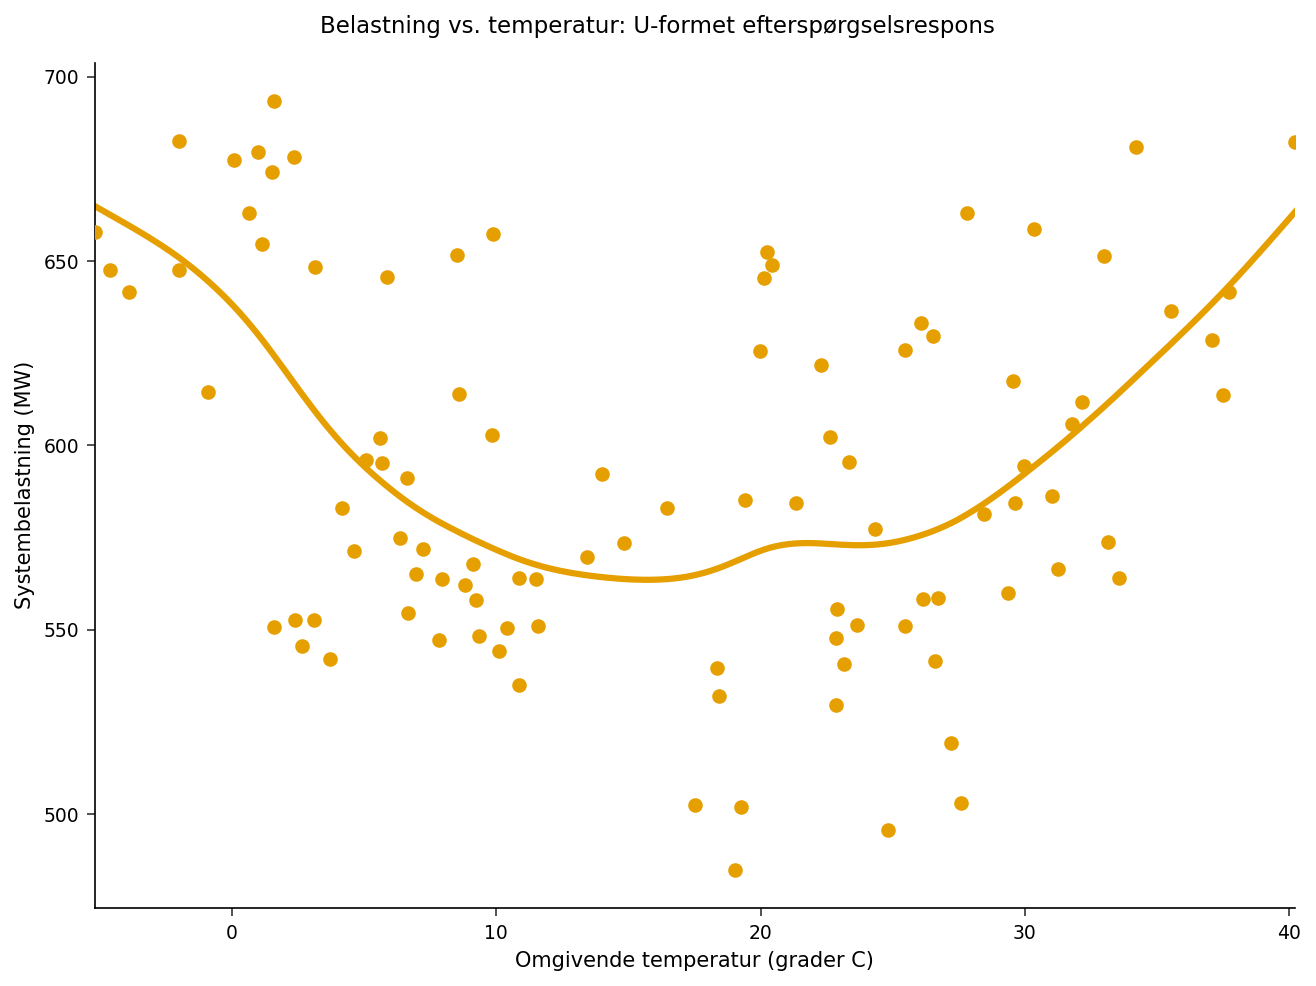

In [4]:
ODS GRAPHICS ON;

PROCEDURE SGPLOT data=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS MÆRKAT="Omgivende temperatur (grader C)";
   YAXIS MÆRKAT="Systembelastning (MW)";
   TITEL "Belastning vs. temperatur: U-formet efterspørgselsrespons";
KØR;

ODS GRAPHICS OFF;


## Trin 5 — Bekræft U-formen numerisk

Plottet gør U-formen synlig; en båndopsummering gør den kvantitativ. Vi inddeler observationerne i temperaturintervaller og rapporterer gennemsnitlig belastning pr. bånd. Hvis efterspørgselsresponsen reelt er U-formet, bør den gennemsnitlige belastning være høj i båndet **Koldt**, falde gennem **Køligt / Behageligt / Varmt** og stige igen i båndet **Meget varmt** — den numeriske signatur, som GAMPL's `s(TEMP_C)`-glatning opfanger.

In [5]:
data work.banded;
   SÆT work.gridload;
   LÆNGDE tempband $16;
   HVIS      temp_c <  5  SÅ tempband = "1 Koldt";
   ELLERS HVIS temp_c < 15  SÅ tempband = "2 Køligt";
   ELLERS HVIS temp_c < 22  SÅ tempband = "3 Behageligt";
   ELLERS HVIS temp_c < 30  SÅ tempband = "4 Varmt";
   ELLERS                      tempband = "5 Meget varmt";
KØR;

PROCEDURE GENNEMSNIT data=work.banded n mean maxdec=1;
   KLASSE tempband;
   VARIABEL load_mw;
   MÆRKAT load_mw="Belastning (MW)" tempband="Temperaturbånd";
   TITEL "Gennemsnitlig belastning efter temperaturbånd";
KØR;


                                     Gennemsnitlig belastning efter temperaturbånd                                      

                                                  The MEANS Procedure

                                      Analysis Variable : load_mw Belastning (MW)

        Temperaturbånd           N Obs           Mean
        ---------------------------------------------
        1 Koldt                     21          626.6
        2 Køligt                    28          579.1
        3 Behageligt                12          573.8
        4 Varmt                     25          573.5
        5 Meget varmt               14          621.6
        ---------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Fortolkning af resultaterne

**Glatningerne genskaber fysikken.** GAMPL's Smoothing Component-tabel tildeler temperaturleddet `s(TEMP_C)` en effektiv frihedsgrad på 5.53 (*p* < 0.0001) og døgnleddet `s(HOUR)` en EDF på 6.87 (*p* < 0.0001) — begge reelt kurvede, præcis den struktur, vi har bygget ind i dataene. Luftfugtighedsleddet `s(HUMIDITY)` krympes til EDF 1.00 (*p* = 0.07): straffen retter det ud til én næsten-lineær frihedsgrad, fordi det ved denne stikprøvestørrelse er alt, hvad dataene understøtter. Det parametriske `daytype`-estimat er −44.5 MW for weekender, hvilket genfinder niveauskiftet på 40 MW for hverdage i den genererende proces.

**Effektive frihedsgrader fortæller historien om bugtethed.** Modellen bruger i alt 15.4 effektive frihedsgrader og lander på en GCV-score på 239.6 (AIC 831.0, skalaestimat 202.7). At begrænse `maxdf=` og fastsætte `df=3` i trin 3 flytter næppe tilpasningen (GCV 240.1, EDF 15.47): straffen havde allerede fastsat temperatur- og timeglatningerne nær 5.5 og 7 EDF af sig selv, så de manuelle begrænsninger er uden reel effekt her — et tegn på, at den automatiske udvælgelse allerede var konservativ.

**Plottet og båndopsummeringen stemmer overens.** Spredningsplottet i trin 4 med sin penaliserede spline-overlejring viser, at belastningen falder fra det kolde yderpunkt til et minimum omkring 15–20 grader C og stiger igen ind i varmen. Båndgennemsnittene i trin 5 gør det numerisk: **Koldt 626.6 MW**, **Køligt 579.1**, **Behageligt 573.8**, **Varmt 573.5**, **Meget varmt 621.6** — højt i begge ender, lavest i det behagelige midterinterval. Det U er præcis det, et enkelt lineært `temp_c`-led ville udjævne væk.

**Hvorfor GAMPL frem for lineær regression her.** Et enkelt lineært `temp_c`-led ville blande opvarmnings- og kølingsregimerne til en næsten flad hældning, hvilket giver dårlige prognoser i begge yderpunkter — netop de timer, hvor netbelastning og prisudsving opstår. Den additive spline-formulering bevarer fortolkeligheden fra en regression (hver driver bidrager med en additiv effekt), samtidig med at dataene bestemmer formen på hver effekt. Naturlige udvidelser for et forsyningsselskab omfatter en `dist=gamma`-tilpasning, hvis belastningen modelleres multiplikativt, en bivariat `spline(temp_c hour)` til at indfange, hvordan døgntoppen forskyder sig med sæsonen, og `by`-processering til at tilpasse separate modeller pr. transformerstation.